In [2]:
# Import numpy and matplotlib libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [ ]:
# Import bicycle count dataset for 2016 (downloaded from https://open.toronto.ca/dataset/bike-share-toronto-ridership-data/):

bikeshare = pd.read_csv('Bikeshare_2016_Q3_Q4.csv')
bikeshare

,trip_id,trip_start_time,trip_stop_time,trip_duration_seconds,from_station_name,to_station_name,user_type
0,53279,7-9-16 1:03,7-9-16 1:15,714,Dundas St E / Regent Park Blvd,Danforth Ave / Ellerbeck St,Member
1,53394,7-9-16 2:15,7-9-16 2:22,417,Riverdale Park North (Broadview Ave),Dundas St E / Regent Park Blvd,Member
2,58314,7-10-16 17:04,7-10-16 17:36,1904,Dundas St E / Regent Park Blvd,Queen St W / Close Ave,Member
3,60784,7-11-16 1:45,7-11-16 1:58,784,Union Station,Dundas St E / Regent Park Blvd,Member
4,93164,7-18-16 13:35,7-18-16 13:42,443,Front St W / Blue Jays Way,Front St / Yonge St (Hockey Hall of Fame),Member
...,...,...,...,...,...,...,...
585526,712377,31/12/2016 23:26,31/12/2016 23:39,824,Union Station,Gould St / Mutual St,Member
585527,712378,31/12/2016 23:26,31/12/2016 23:34,478,Bay St / College St (East Side),Beverly St / Dundas St W,Member
585528,712379,31/12/2016 23:33,31/12/2016 23:38,271,Temperance St / Yonge St,Victoria St / Gould St (Ryerson University),Member
585529,712380,31/12/2016 23:37,31/12/2016 23:58,1253,Christie St / Benson Ave (Wychwood Barns),Wellesley St E / Yonge St Green P,Member


In [ ]:
# Calculate basic summary statistics as a supplement to the boxplot. Units for trip duration are in seconds.

statistics = bikeshare.groupby('user_type')['trip_duration_seconds'].agg(Min='min', Median='median', Mean='mean', Max='max')
statistics

,Min,Median,Mean,Max
user_type,,,,
Casual,60,1125.0,1748.612115,14400
Member,60,590.0,676.049550,14334


Text(0.5, 1.0, 'Bikeshare ride durations in Toronto during Q3 and Q4')

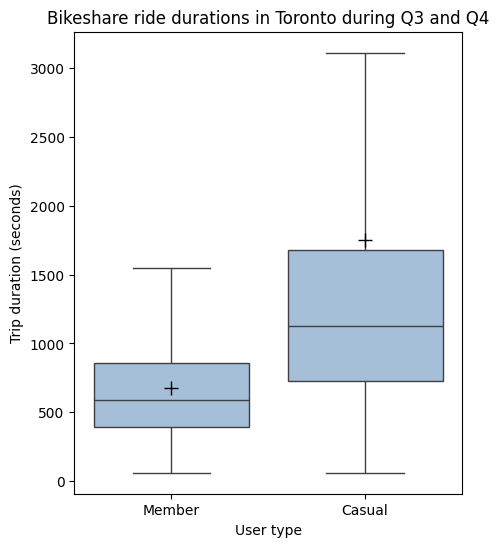

In [ ]:
# Import seaborn to create a boxplot
import seaborn as sns

plt.figure(figsize=(5,6))  # Define figure size as 5x6"
ax = sns.boxplot(x = "user_type", y = "trip_duration_seconds", # Create boxplot with "Trip duration" as the variable and user type as the categories/x-value 
                 data = bikeshare, 
                 showmeans = "True",  # Show the mean values of each box plot
                 meanprops={"marker": "+", # Indicate "+" as the symbol of the mean value; colour and size also specified below
                       "markeredgecolor": "black", 
                       "markersize": "10"},
            showfliers = False,  # Hide outliers because there are thousands of them
            boxprops={"facecolor": (.3, .5, .7, .5)}) # Define colour of the boxes
ax.set(xlabel='User type', ylabel='Trip duration (seconds)')  # Label x and y with descriptions that are easier to read than the variable names in the .csv
ax.set_title('Bikeshare ride durations in Toronto during Q3 and Q4') # Add title to figure
